Torch: 2.10.0+cu128
Device: cuda
Classes: ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
Loading pretrained MobileNetV3...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 129MB/s] 



Per Class Metrics
short sleeve top
Precision: 0.708110992529349
Recall: 0.6436019723547005
F1: 0.6743171712894347
AUC: 0.7458693612540521

trousers
Precision: 0.7573978123200921
Recall: 0.6928586475668843
F1: 0.7236921722867045
AUC: 0.8597191986238046

shorts
Precision: 0.5271705184259837
Recall: 0.4084200338736995
F1: 0.46025903203817314
AUC: 0.8020609832217882

long sleeve top
Precision: 0.5851063829787234
Recall: 0.32538877620013523
F1: 0.41820551814034324
AUC: 0.767448695007335

skirt
Precision: 0.771581359816654
Recall: 0.3108170487767349
F1: 0.4431282220028518
AUC: 0.8273574750170357


Epoch 1
Loss: 0.4800076181233538
Macro Precision: 0.6698734132141605
Macro Recall: 0.47621729575443084
Macro F1: 0.5439204231515015
Micro F1: 0.5981438652671529
Macro AUC: 0.8004911426248033
NEW BEST MODEL — SAVING

Per Class Metrics
short sleeve top
Precision: 0.7174074074074074
Recall: 0.6263034516207259
F1: 0.668766993224289
AUC: 0.7434195763960413

trousers
Precision: 0.7678930557198628
Recall

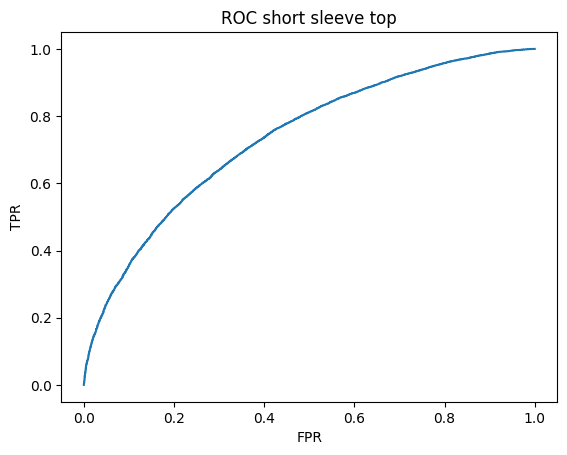

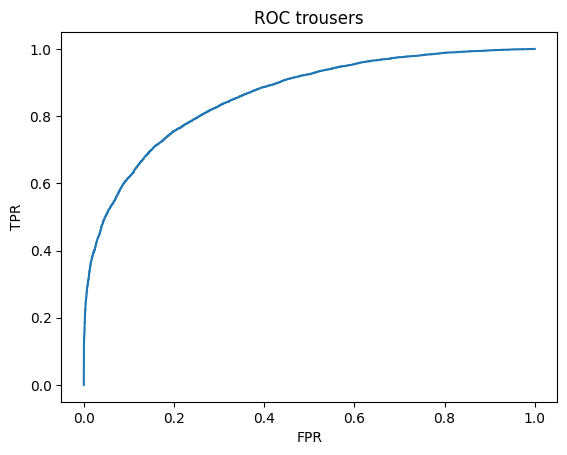

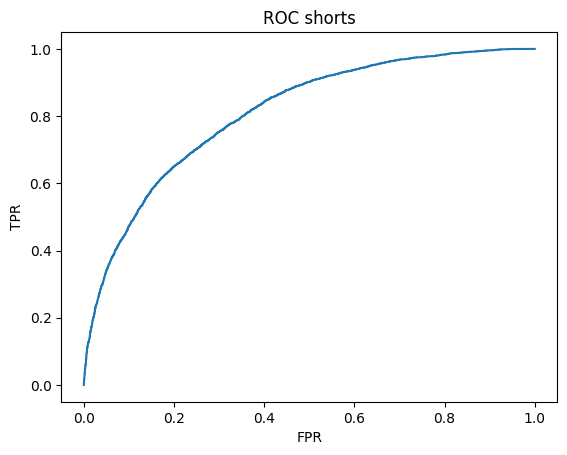

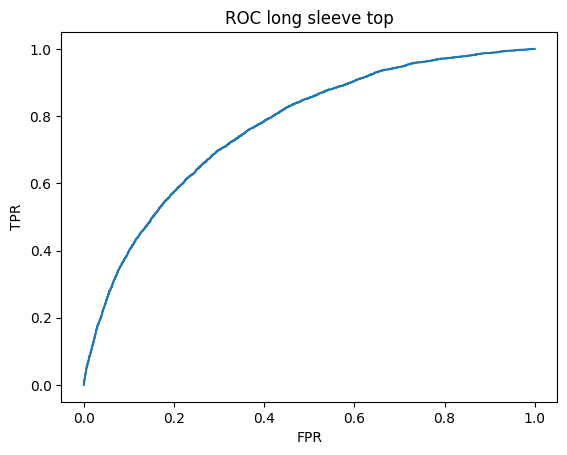

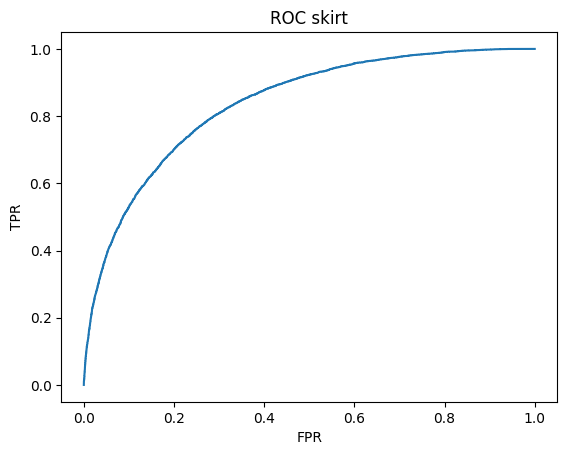

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
import json
import numpy as np
import warnings
from PIL import Image
from tqdm import tqdm

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from torchvision import transforms
from torchvision.models import mobilenet_v3_large

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt


print("Torch:", torch.__version__)

# ============================================================
# DEVICE (T4)
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================================
# PATHS (UNCHANGED)
# ============================================================
BASE_PATH = "/kaggle/input/datasets/iharshsinha/deepfashion2-top5-processed/processed"

TRAIN_IMAGES = os.path.join(BASE_PATH,"train/images")
TRAIN_ANNOS = os.path.join(BASE_PATH,"train/annos")

VAL_IMAGES = os.path.join(BASE_PATH,"validation/images")
VAL_ANNOS = os.path.join(BASE_PATH,"validation/annos")

SAVE1 = "/kaggle/working/"
SAVE2 = "/kaggle/temp/"
SAVE3 = "/kaggle/working/output/"
os.makedirs(SAVE3,exist_ok=True)


# ============================================================
# LABEL MAP
# ============================================================
label_map = {
    "short sleeve top":0,
    "trousers":1,
    "shorts":2,
    "long sleeve top":3,
    "skirt":4
}

num_classes = len(label_map)
class_names = list(label_map.keys())

print("Classes:", class_names)


# ============================================================
# LAZY DATASET (CRASH FIX)
# ============================================================
class FashionDataset(Dataset):

    def __init__(self, annos_dir, images_dir, transform):
        self.annos_dir = annos_dir
        self.images_dir = images_dir
        self.files = [f for f in os.listdir(annos_dir) if f.endswith(".json")]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]

        with open(os.path.join(self.annos_dir,file)) as f:
            data = json.load(f)

        labels = np.zeros(num_classes)

        for k,v in data.items():
            if k.startswith("item"):
                cat = v["category_name"]
                if cat in label_map:
                    labels[label_map[cat]] = 1

        img_path = os.path.join(self.images_dir,file.replace(".json",".jpg"))
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        return img, torch.tensor(labels, dtype=torch.float32)


# ============================================================
# TRANSFORMS
# ============================================================
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


# ============================================================
# DATALOADER (SAFE)
# ============================================================
batch_size = 64

train_loader = DataLoader(
    FashionDataset(TRAIN_ANNOS,TRAIN_IMAGES,train_tf),
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    FashionDataset(VAL_ANNOS,VAL_IMAGES,val_tf),
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ============================================================
# MODEL (STRICT TL)
# ============================================================
print("Loading pretrained MobileNetV3...")

try:
    model = mobilenet_v3_large(weights="IMAGENET1K_V1")
except:
    raise RuntimeError("Pretrained weights failed. Enable internet.")


# freeze backbone
for p in model.parameters():
    p.requires_grad = False

model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

model = model.to(device)


# ============================================================
# LOSS + OPTIMIZER
# ============================================================
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scaler = GradScaler()


# ============================================================
# TRAIN
# ============================================================
def train_epoch():

    model.train()
    total_loss = 0

    for imgs,labels in train_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast("cuda"):
            out = model(imgs)
            loss = criterion(out,labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss/len(train_loader)


# ============================================================
# EVALUATION
# ============================================================
def evaluate():

    model.eval()

    preds=[]
    targets=[]

    with torch.no_grad():

        for imgs,labels in val_loader:

            imgs = imgs.to(device)

            out = model(imgs)
            probs = torch.sigmoid(out).cpu().numpy()

            preds.append(probs)
            targets.append(labels.numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    preds_bin = (preds > 0.5).astype(int)

    print("\nPer Class Metrics")

    for i,c in enumerate(class_names):

        p = precision_score(targets[:,i],preds_bin[:,i],zero_division=0)
        r = recall_score(targets[:,i],preds_bin[:,i],zero_division=0)
        f = f1_score(targets[:,i],preds_bin[:,i],zero_division=0)
        auc = roc_auc_score(targets[:,i],preds[:,i])

        print(c)
        print("Precision:",p)
        print("Recall:",r)
        print("F1:",f)
        print("AUC:",auc)
        print()

    return (
        f1_score(targets,preds_bin,average="macro"),
        f1_score(targets,preds_bin,average="micro"),
        precision_score(targets,preds_bin,average="macro"),
        recall_score(targets,preds_bin,average="macro"),
        roc_auc_score(targets,preds,average="macro"),
        preds,
        targets
    )


# ============================================================
# TRAIN LOOP
# ============================================================
epochs = 7
best_f1 = 0

for epoch in range(epochs):

    loss = train_epoch()

    f1_macro,f1_micro,precision,recall,auc,preds,targets = evaluate()

    print("\nEpoch",epoch+1)
    print("Loss:",loss)
    print("Macro Precision:",precision)
    print("Macro Recall:",recall)
    print("Macro F1:",f1_macro)
    print("Micro F1:",f1_micro)
    print("Macro AUC:",auc)

    if f1_macro > best_f1:

        best_f1 = f1_macro

        print("NEW BEST MODEL — SAVING")

        state_dict = model.state_dict()

        torch.save(state_dict,"mobilenetv3_transfer.pth")
        torch.save(state_dict,SAVE1+"mobilenetv3_transfer.pth")
        torch.save(state_dict,SAVE3+"mobilenetv3_transfer.pth")


# ============================================================
# ROC CURVES
# ============================================================
for i,c in enumerate(class_names):

    fpr,tpr,_ = roc_curve(targets[:,i],preds[:,i])

    plt.figure()
    plt.plot(fpr,tpr)
    plt.title("ROC "+c)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()